# Week 6 — Readability experiment

The question: **if I ask the model to write more simply, does the answer stop being faithful to
the source?** And does that cost differ depending on the medical topic?

Why it's worth asking. Patient materials should sit around 5th-8th grade; my week 4 answers came
out around grade 10-11. So simplification is something the system needs to do. But a 6th grade
rewrite has to reword the source heavily, and reworded medical text is exactly where meaning
gets lost. A 2026 JMIR review of 31 simplification studies found models struggle to hit target
levels and that accuracy is often compromised - but nobody has measured the trade-off directly,
and nobody has asked whether it varies by medical category.

**Design.** Every question gets answered three times - no instruction, grade 9, grade 6 - with the
same retrieved passages and the same model. Only one line of the prompt changes. That makes it a
paired comparison: I can look at the same question across levels rather than comparing group means,
which controls for questions being easy or hard.

**Two things get measured, and they're different questions:**
1. does the instruction actually work - does asking for grade 6 produce grade 6 text?
2. if it does, what does it cost in faithfulness?

**What's frozen and why.** k stays at 5. My pilot had hit rate 1.00 at k=5, so retrieval isn't the
bottleneck and varying k can't tell me much - and if I changed k later I'd have to re-run all of
this. Baseline runs at one level only; it's the control for "does retrieval help", which the pilot
already answered (0.97 vs 0.84), so paying for it three times over buys nothing.

**Protocol.** Everything below runs on dev. Prompts get adjusted on dev if the grade-6 instruction
isn't landing. Then prompts freeze and held-out runs **once**, and those are the reported numbers.
Comparing dev to held-out at the end tells me whether I overfitted the prompts.

In [13]:
import json
import re
import time
from collections import Counter, defaultdict
from datetime import datetime, timezone

import chromadb
import ollama
import numpy as np
import pandas as pd
import textstat
from sentence_transformers import SentenceTransformer
import matplotlib_inline
import matplotlib


Matplotlib is building the font cache; this may take a moment.


In [2]:
GENERATOR_MODEL = 'mistral:7b-instruct'
JUDGE_MODEL = 'llama3.1:8b'
TEMPERATURE = 0
SEED = 42

DB_DIR = 'chroma_db'
COLLECTION = 'medlineplus_english'
EMBED_MODEL = 'BAAI/bge-small-en-v1.5'
TOP_K = 5              # frozen - see header
MAX_PER_TOPIC = 2

LEVELS = ['none', 'grade9', 'grade6']
SPLIT = 'dev'          # switch to 'heldout' ONCE, at the very end
RUN_LOG = f'wk6_readability_{SPLIT}.jsonl'

REFUSAL_MARKER = "i don't have reliable information"

RESUME = True          # skip questions already in the log, so a crash isn't fatal

In [3]:
# ---- everything below here is lifted from the v2 harness, unchanged, so results stay comparable
def generate(prompt, model=GENERATOR_MODEL):
    resp = ollama.chat(model=model, messages=[{'role': 'user', 'content': prompt}],
                       options={'temperature': TEMPERATURE, 'seed': SEED})
    return resp['message']['content'].strip()


embedder = SentenceTransformer(EMBED_MODEL)
coll = chromadb.PersistentClient(path=DB_DIR).get_collection(COLLECTION)


def retrieve(query, k=TOP_K, max_per_topic=MAX_PER_TOPIC):
    q_emb = embedder.encode('Represent this sentence for searching relevant passages: ' + query)
    res = coll.query(query_embeddings=[q_emb.tolist()], n_results=k * 10)
    hits, spill, per_topic = [], [], Counter()
    for doc, meta, dist in zip(res['documents'][0], res['metadatas'][0], res['distances'][0]):
        hit = {'text': doc, 'title': meta['title'], 'url': meta['url'],
               'group': meta['group'], 'similarity': round(1 - dist, 3)}
        if per_topic[meta['topic_id']] >= max_per_topic:
            spill.append(hit); continue
        per_topic[meta['topic_id']] += 1
        hits.append(hit)
        if len(hits) == k: break
    if len(hits) < k: hits.extend(spill[:k - len(hits)])
    return hits


RAG_PROMPT = """You are a patient education assistant. Answer the patient's question using ONLY the information in the passages below.

Rules:
- Use only facts stated in the passages. Do not add anything from your own knowledge.
- After each fact, cite the passage it came from by its topic title in square brackets, like [Heart Failure].
{reading_level}- If the passages do not contain the information needed to answer, say exactly: \"I don't have reliable information to answer that. Please ask your health care provider.\"
- Do not give a diagnosis. Do not recommend changing any medicine or dose.

Passages:
{passages}

Patient's question: {question}

Answer:"""

BASELINE_PROMPT = """You are a patient education assistant. Answer the patient's question.

Rules:
{reading_level}- Do not give a diagnosis. Do not recommend changing any medicine or dose.

Patient's question: {question}

Answer:"""

READING_LEVELS = {
    'grade6': '- Write so a 6th grade reader can understand it. Use short sentences and simple words.\n',
    'grade9': '- Write so a 9th grade reader can understand it.\n',
    'none':   '- Write in plain, everyday language a patient can understand.\n',
}

CITE_RE = re.compile(r'\[([^\]]+)\]')

def format_passages(hits):
    return '\n\n---\n\n'.join(f"Topic: {h['title']}\n{h['text']}" for h in hits)

def strip_citations(t):
    return re.sub(r'\s{2,}', ' ', CITE_RE.sub('', t)).strip()

def is_refusal(a):
    return REFUSAL_MARKER in a.lower()

def readability(a):
    c = strip_citations(a)
    if len(c.split()) < 10:
        return {'fkgl': None, 'fre': None, 'words': len(c.split())}
    return {'fkgl': round(textstat.flesch_kincaid_grade(c), 1),
            'fre': round(textstat.flesch_reading_ease(c), 1), 'words': len(c.split())}

def citation_scores(a, hits):
    cited = [c.strip() for c in CITE_RE.findall(a)]
    if not cited:
        return {'cited_any': False, 'citation_precision': None, 'n_citations': 0}
    retrieved = {h['title'].lower() for h in hits}
    return {'cited_any': True,
            'citation_precision': round(sum(1 for c in cited if c.lower() in retrieved) / len(cited), 2),
            'n_citations': len(cited)}

def split_sentences(t):
    return [p.strip() for p in re.split(r'(?<=[.!?])\s+', strip_citations(t)) if len(p.strip()) > 20]

FAITHFUL_PROMPT = """Here are passages from a medical reference, and one sentence from an answer that was written using them.

Passages:
{passages}

Sentence: \"{sentence}\"

Is the sentence supported by the passages? A sentence counts as supported if its factual claims appear in the passages, even if it is worded differently or uses simpler words. General advice to consult a doctor counts as supported.

Reply with exactly one word: YES or NO."""

RELEVANCY_PROMPT = """A patient asked: \"{question}\"

They received this answer:
\"{answer}\"

On a scale of 1 to 5, how well does the answer address the patient's actual question? 1 = not at all, 3 = partially, 5 = fully addresses it.

Reply with only the number."""

CONTEXT_PROMPT = """A patient asked: "{question}"

Here is one passage that was retrieved to help answer it:
\"\"\"{chunk}\"\"\"

Does this passage contain information that helps answer the patient's question? Answer YES if it is useful, NO if it is off-topic or unhelpful.

Reply with exactly one word: YES or NO."""

print('index loaded:', coll.count(), 'chunks')

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 7107.66it/s]


index loaded: 10337 chunks


## Retrieval scored once per question, not once per answer

The pilot recomputed hit rate, MRR and context precision for every answer. But retrieval doesn't
depend on the reading level or the arm - it's the same five passages every time. So it was doing
the same work six times per question, and context precision costs five judge calls each time.
Scoring it once per question and attaching the result to all six answers cuts roughly 2.5 hours
off the run and changes nothing about the numbers.

In [4]:
def score_retrieval_once(question, hits, gold_title):
    titles = [h['title'] for h in hits]
    if gold_title in titles:
        rank = titles.index(gold_title) + 1
        r = {'hit': 1, 'rank': rank, 'rr': round(1 / rank, 3)}
    else:
        r = {'hit': 0, 'rank': None, 'rr': 0.0}

    verdicts = [generate(CONTEXT_PROMPT.format(question=question, chunk=h['text']),
                         model=JUDGE_MODEL).strip().upper().startswith('YES') for h in hits]
    r['context_precision'] = round(sum(verdicts) / len(verdicts), 2) if verdicts else None
    r['useful_chunks'] = sum(verdicts)
    return r


def score_answer(record, arm):
    """metrics that DO depend on the answer - so these run per answer."""
    s = {'arm': arm, 'level': record['level']}
    s.update(readability(record['answer']))

    out = generate(RELEVANCY_PROMPT.format(question=record['question'],
                                           answer=strip_citations(record['answer'])),
                   model=JUDGE_MODEL)
    m = re.search(r'[1-5]', out)
    s['relevancy'] = int(m.group()) if m else None

    if is_refusal(record['answer']):
        s.update({'faithfulness': None, 'n_sentences': 0, 'unsupported': [], 'refused': True})
    else:
        sentences = split_sentences(record['answer'])
        if not sentences:
            s.update({'faithfulness': None, 'n_sentences': 0, 'unsupported': [], 'refused': False})
        else:
            passages = format_passages(record['hits'])
            verdicts, unsupported = [], []
            for sent in sentences:
                ok = generate(FAITHFUL_PROMPT.format(passages=passages, sentence=sent),
                              model=JUDGE_MODEL).strip().upper().startswith('YES')
                verdicts.append(ok)
                if not ok:
                    unsupported.append(sent)
            s.update({'faithfulness': round(sum(verdicts) / len(verdicts), 2),
                      'n_sentences': len(sentences), 'unsupported': unsupported, 'refused': False})

    if arm == 'rag':
        s.update(citation_scores(record['answer'], record['hits']))
    return s

## The run

Per question: retrieve once, score retrieval once, then generate RAG at three levels plus one
baseline. Four answers per question instead of six, and one retrieval scoring instead of six.

Writes to the log as it goes and skips anything already logged, so if it dies overnight I restart
and it picks up where it stopped.

In [5]:
questions = json.load(open(f'test_queries_{SPLIT}.json', encoding='utf-8'))
print(f'{SPLIT}: {len(questions)} questions')

done = set()
if RESUME:
    try:
        with open(RUN_LOG, encoding='utf-8') as f:
            done = {json.loads(line)['question'] for line in f}
        print(f'resuming - {len(done)} questions already logged')
    except FileNotFoundError:
        pass

todo = [q for q in questions if q['question'] not in done]
print(f'{len(todo)} to do -> {len(todo) * 4} answers')

dev: 115 questions
115 to do -> 460 answers


In [6]:
t_start = time.time()

for i, q in enumerate(todo, 1):
    hits = retrieve(q['question'])
    retr = score_retrieval_once(q['question'], hits, q['topic_title'])   # once, reused below
    passages = format_passages(hits)

    rows = []
    for level in LEVELS:
        prompt = RAG_PROMPT.format(passages=passages, question=q['question'],
                                   reading_level=READING_LEVELS[level])
        rec = {'question': q['question'], 'answer': generate(prompt), 'hits': hits, 'level': level}
        rows.append(('rag', rec, score_answer(rec, 'rag')))

    # baseline at one level only - it's the retrieval control, not part of the readability test
    b_prompt = BASELINE_PROMPT.format(question=q['question'], reading_level=READING_LEVELS['none'])
    b_rec = {'question': q['question'], 'answer': generate(b_prompt), 'hits': hits, 'level': 'none'}
    rows.append(('baseline', b_rec, score_answer(b_rec, 'baseline')))

    with open(RUN_LOG, 'a', encoding='utf-8') as f:
        for arm, rec, sc in rows:
            f.write(json.dumps({
                'timestamp': datetime.now(timezone.utc).isoformat(),
                'question': q['question'], 'answer': rec['answer'],
                'retrieved': [{'title': h['title'], 'url': h['url'],
                               'similarity': h['similarity']} for h in hits],
                'scores': {**sc, **retr},
                'topic_title': q['topic_title'], 'group': q['group'], 'qtype': q['qtype'],
                'split': SPLIT,
                'config': {'generator': GENERATOR_MODEL, 'judge': JUDGE_MODEL,
                           'temperature': TEMPERATURE, 'seed': SEED, 'k': TOP_K,
                           'embed_model': EMBED_MODEL, 'level': rec['level']},
            }, ensure_ascii=False) + '\n')

    if i % 5 == 0 or i == len(todo):
        el = time.time() - t_start
        print(f'  {i}/{len(todo)} | {el/60:.0f} min | est. {el/i*(len(todo)-i)/60:.0f} min left')

print(f'\ndone in {(time.time() - t_start)/60:.0f} min')

  5/115 | 16 min | est. 362 min left
  10/115 | 38 min | est. 399 min left
  15/115 | 60 min | est. 400 min left
  20/115 | 85 min | est. 402 min left
  25/115 | 105 min | est. 379 min left
  30/115 | 124 min | est. 351 min left
  35/115 | 145 min | est. 330 min left
  40/115 | 162 min | est. 303 min left
  45/115 | 180 min | est. 280 min left
  50/115 | 196 min | est. 255 min left
  55/115 | 214 min | est. 233 min left
  60/115 | 233 min | est. 214 min left
  65/115 | 251 min | est. 193 min left
  70/115 | 266 min | est. 171 min left
  75/115 | 282 min | est. 150 min left
  80/115 | 299 min | est. 131 min left
  85/115 | 315 min | est. 111 min left
  90/115 | 331 min | est. 92 min left
  95/115 | 350 min | est. 74 min left
  100/115 | 369 min | est. 55 min left
  105/115 | 388 min | est. 37 min left
  110/115 | 408 min | est. 19 min left
  115/115 | 427 min | est. 0 min left

done in 427 min


## Question 1 — did the instruction actually work?

Before asking what simplification costs, check it happened. If grade6 doesn't read easier than
none, there's no trade-off to measure and the rest is meaningless.

In [7]:
runs = [json.loads(l) for l in open(RUN_LOG, encoding='utf-8')]
df = pd.DataFrame([{'question': r['question'], 'group': r['group'], 'qtype': r['qtype'],
                    **{k: v for k, v in r['scores'].items() if k != 'unsupported'}} for r in runs])
rag = df[df.arm == 'rag'].copy()
print(f'{len(df)} answers | {df.question.nunique()} questions')

print('\nreading level actually achieved (FKGL, lower = easier):')
print(rag.groupby('level')[['fkgl', 'fre', 'words']].agg(['mean', 'std']).round(1))

target = {'grade6': 6, 'grade9': 9}
print('\ndid it hit the target?')
for lvl, t in target.items():
    sub = rag[(rag.level == lvl) & rag.fkgl.notna()]
    print(f'  {lvl}: mean FKGL {sub.fkgl.mean():.1f} vs target {t} '
          f'| within 1 grade: {(sub.fkgl.sub(t).abs() <= 1).mean():.0%} of answers')

460 answers | 115 questions

reading level actually achieved (FKGL, lower = easier):
        fkgl        fre       words      
        mean  std  mean   std  mean   std
level                                    
grade6   9.6  3.0  59.5  13.3  79.7  44.9
grade9  10.3  2.6  55.1  12.5  88.4  48.0
none    10.6  2.8  54.0  13.7  87.2  51.0

did it hit the target?
  grade6: mean FKGL 9.6 vs target 6 | within 1 grade: 16% of answers
  grade9: mean FKGL 10.3 vs target 9 | within 1 grade: 37% of answers


## Question 2 — what did it cost?

Paired: for each question, grade6 minus none. Comparing group means would let easy and hard
questions muddy the picture; pairing removes that because it's the same question both times.

Reporting a 95% confidence interval rather than a p-value. With 7 categories to look at, p-values
would invite reading noise as signal.

In [8]:
wide = rag.pivot_table(index='question', columns='level',
                       values=['fkgl', 'faithfulness', 'words', 'citation_precision'])
wide.columns = [f'{a}_{b}' for a, b in wide.columns]
wide = wide.join(rag.groupby('question')['group'].first())


def ci95(x):
    x = pd.Series(x).dropna()
    if len(x) < 2:
        return (np.nan, np.nan, np.nan, 0)
    m, se = x.mean(), x.std(ddof=1) / np.sqrt(len(x))
    return (m, m - 1.96 * se, m + 1.96 * se, len(x))


print('paired change vs the uncontrolled condition:\n')
for lvl in ['grade9', 'grade6']:
    for metric in ['fkgl', 'faithfulness']:
        a, b = f'{metric}_{lvl}', f'{metric}_none'
        if a not in wide or b not in wide:
            continue
        m, lo, hi, n = ci95(wide[a] - wide[b])
        flag = '' if (lo < 0 < hi) else '   <-- CI excludes zero'
        print(f'  {lvl:7s} {metric:13s} {m:+.2f}  [95% CI {lo:+.2f}, {hi:+.2f}]  n={n}{flag}')
    print()

paired change vs the uncontrolled condition:

  grade9  fkgl          -0.32  [95% CI -0.68, +0.03]  n=115
  grade9  faithfulness  -0.01  [95% CI -0.03, +0.01]  n=91

  grade6  fkgl          -1.03  [95% CI -1.38, -0.68]  n=115   <-- CI excludes zero
  grade6  faithfulness  -0.02  [95% CI -0.03, +0.00]  n=88



In [9]:
# is the trade-off real at the level of individual questions? count which way each one moved
d = (wide['faithfulness_grade6'] - wide['faithfulness_none']).dropna()
print(f'questions where grade6 was LESS faithful: {(d < 0).sum()}')
print(f'                          no change     : {(d == 0).sum()}')
print(f'                          MORE faithful : {(d > 0).sum()}')
print(f'\nbiggest drops:')
for q, v in d.nsmallest(5).items():
    print(f'  {v:+.2f}  {q[:70]}')

questions where grade6 was LESS faithful: 7
                          no change     : 78
                          MORE faithful : 3

biggest drops:
  -0.50  Who is at risk for Cataract?
  -0.33  How to diagnose Hemorrhoids?
  -0.25  What are the treatments for Transient Ischemic Attack?
  -0.25  What is (are) Chlamydia Infections?
  -0.25  What is (are) Gout?


## Question 3 — does the cost differ by medical category?

The novel bit. Only the pre-registered analysis categories get individual claims - the tier list
was fixed before any of this ran, so I can't pick favourable ones after the fact.

Reading this honestly: 7 categories means 7 comparisons, so by chance alone one could look
"significant". These are exploratory, and with 7-11 questions each the intervals will be wide.

In [10]:
cats = json.load(open('analysis_categories.json', encoding='utf-8'))['analysis_categories']
wide['delta_faith'] = wide['faithfulness_grade6'] - wide['faithfulness_none']
wide['delta_fkgl'] = wide['fkgl_grade6'] - wide['fkgl_none']

print('faithfulness change from simplifying to grade 6, by category:\n')
rows = []
for g in cats:
    sub = wide[wide.group == g]
    m, lo, hi, n = ci95(sub['delta_faith'])
    fk, *_ = ci95(sub['delta_fkgl'])
    rows.append({'category': g, 'n': n, 'faith_change': round(m, 3),
                 'ci_low': round(lo, 3), 'ci_high': round(hi, 3), 'fkgl_change': round(fk, 2)})
cat_df = pd.DataFrame(rows).sort_values('faith_change')
print(cat_df.to_string(index=False))

print('\naggregate-only categories pooled (no individual claims):')
pooled = wide[~wide.group.isin(cats)]
m, lo, hi, n = ci95(pooled['delta_faith'])
print(f'  {m:+.3f}  [95% CI {lo:+.3f}, {hi:+.3f}]  n={n}')

cat_df.to_csv(f'wk6_category_results_{SPLIT}.csv', index=False)

faithfulness change from simplifying to grade 6, by category:

                    category  n  faith_change  ci_low  ci_high  fkgl_change
Blood, Heart and Circulation  3        -0.083  -0.247    0.080        -0.91
   Bones, Joints and Muscles  5        -0.050  -0.148    0.048        -1.51
            Digestive System  6        -0.047  -0.159    0.066        -0.86
                  Infections  9        -0.028  -0.082    0.027        -1.12
  Mental Health and Behavior  3         0.000   0.000    0.000        -2.62
                     Cancers  8         0.018  -0.017    0.052        -1.57
            Brain and Nerves  6         0.028  -0.027    0.084        -1.74

aggregate-only categories pooled (no individual claims):
  -0.015  [95% CI -0.036, +0.006]  n=48


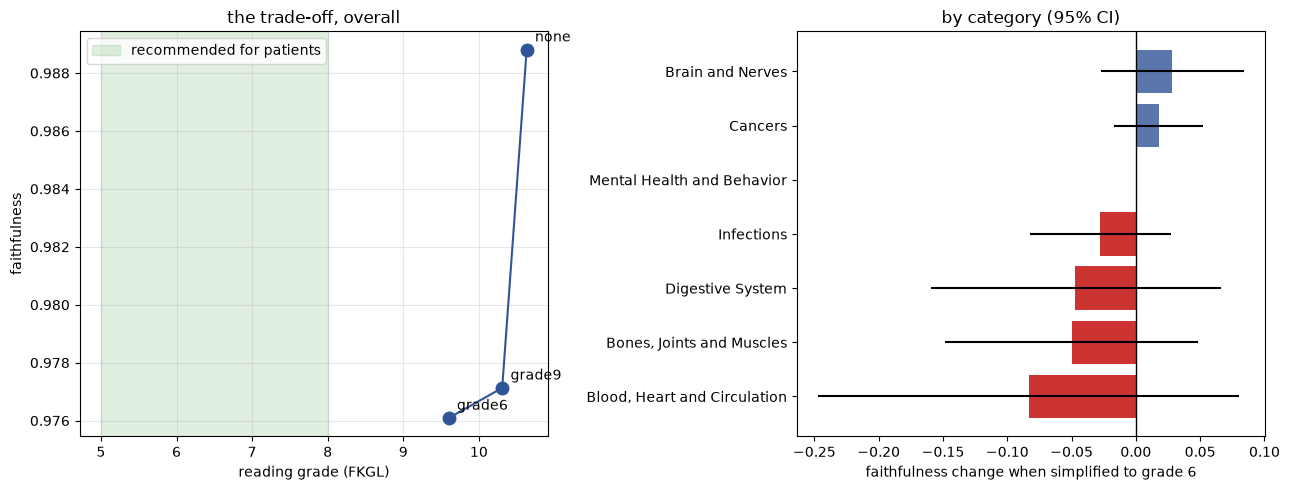

In [14]:
# the headline plot: readability against faithfulness, one line per category
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

means = rag.groupby('level')[['fkgl', 'faithfulness']].mean().reindex(LEVELS)
axes[0].plot(means.fkgl, means.faithfulness, 'o-', color='#2f5597', markersize=9)
for lvl, r in means.iterrows():
    axes[0].annotate(lvl, (r.fkgl, r.faithfulness), textcoords='offset points', xytext=(6, 6))
axes[0].axvspan(5, 8, alpha=0.12, color='green', label='recommended for patients')
axes[0].set_xlabel('reading grade (FKGL)'); axes[0].set_ylabel('faithfulness')
axes[0].set_title('the trade-off, overall'); axes[0].legend(); axes[0].grid(alpha=0.3)

cd = cat_df.dropna(subset=['faith_change'])
axes[1].barh(cd.category, cd.faith_change,
             xerr=[cd.faith_change - cd.ci_low, cd.ci_high - cd.faith_change],
             color=['#c00000' if v < 0 else '#2f5597' for v in cd.faith_change], alpha=0.8)
axes[1].axvline(0, color='black', lw=1)
axes[1].set_xlabel('faithfulness change when simplified to grade 6')
axes[1].set_title('by category (95% CI)')
plt.tight_layout()
plt.savefig(f'wk6_tradeoff_{SPLIT}.png', dpi=150)
plt.show()

## Check the metric didn't cause the result

The thing that would invalidate all of this: the judge marking a correct simple paraphrase as
unsupported just because it's worded differently. If that's happening I'd see a drop that isn't
real. This pulls the sentences the judge rejected at grade 6 - I read them and decide whether the
judge was right. If most look like fair paraphrases of the source, the result is an artifact and
the judge prompt needs fixing before anything gets reported.

In [15]:
flagged = [(r['question'], s) for r in runs
           if r['scores'].get('level') == 'grade6' and r['scores'].get('arm') == 'rag'
           for s in r['scores'].get('unsupported', [])]

print(f'{len(flagged)} sentences judged unsupported at grade 6\n')
for q, s in flagged[:15]:
    print(f'  Q: {q[:58]}')
    print(f'     {s[:105]}\n')

8 sentences judged unsupported at grade 6

  Q: What are the treatments for Transient Ischemic Attack?
     The treatment for a Transient Ischemic Attack (TIA) is not specifically mentioned in the provided passage

  Q: What are the symptoms of Abdominal Adhesions?
     Sometimes, they can also cause symptoms such as swelling in the abdomen and loss of appetite .

  Q: What is (are) Gout?
     Gout can also affect other joints like wrists .

  Q: Who is at risk for Cataract?
     Additionally, anyone can have a higher risk of developing cataracts if other family members have had them

  Q: How to diagnose Hemorrhoids?
     For internal hemorrhoids, they may insert a lubricated, gloved finger into your rectum to feel for anythi

  Q: What is (are) Bedbugs?
     Bed bugs are small parasites that feed on people's blood.

  Q: What is (are) Chlamydia Infections?
     They are caused by bacteria called Chlamydia trachomatis .

  Q: Do you have information about Pet Health
     However, the 

## Notes

(fill in after running)

- did the instruction work - FKGL at none / grade9 / grade6, and how often it hit the target:
- overall faithfulness change from simplifying, with the CI - does it exclude zero:
- how many individual questions got worse vs better:
- category differences - which look real given the intervals, and which are too thin to call:
- the flagged grade6 sentences - fair calls by the judge, or is it punishing paraphrase:
- refusal rate by level (does simplifying make it refuse more):
- anything to change before the held-out run: